### Import LIbraries

In [12]:
import pandas as pd
import numpy as np
import os
from matplotlib import pyplot
from matplotlib.ticker import FormatStrFormatter
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras import backend as K

import matplotlib.pyplot as plt 
from matplotlib.ticker import FormatStrFormatter

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.preprocessing import StandardScaler
from datetime import datetime
import sys

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')

USE_CUDA = False
EPOCHS = 10
comms_round = 20

### Dataset

In [13]:
%store -r Fed_X_Train_st
%store -r Fed_X_Test_st

%store -r Fed_y_Train
%store -r Fed_y_Test

merged_dataset = pd.concat([Fed_X_Train_st, Fed_y_Train], axis=1)
Fed_X_Test_st = Fed_X_Test_st.drop(columns=['unit_number'])

In [14]:
feature_columns = ['time_cycles', 'LPC_Outlet_Temperature', 'HPC_Outlet_Temperature', 'LPT Outlet Temperature', 'Bypass-Duct Pressure', 
                'HPC Outlet Pressure', 'Physical Fan Speed', 'Physical Core Speed', 'HPC Outlet Static Pressure',
                'Ratio of Fuel Flow to Ps30', 'Corrected Fan Speed', 'Bypass Ratio', 'Bleed Enthalpy',
                'High-Pressure Turbines Cool Air Flow', 'Low-Pressure Turbines Cool Air Flow']

features = merged_dataset[feature_columns]

labels = merged_dataset['RUL']

### Data Partition

In [15]:
grouped = merged_dataset.groupby('unit_number')

unit_numbers = merged_dataset['unit_number'].unique()

np.random.seed(42)
np.random.shuffle(unit_numbers)

num_clients = 10
unit_subsets = np.array_split(unit_numbers, num_clients)

client_data = {f"client_{i+1}": pd.DataFrame() for i in range(num_clients)}

for i, unit_subset in enumerate(unit_subsets):
    client_data[f"client_{i+1}"] = grouped.filter(lambda x: x.name in unit_subset)

for i in range(num_clients):
    print(f"Client {i+1} dataset size: {len(client_data[f'client_{i+1}'])}")

client_1_data = client_data["client_1"]
client_2_data = client_data["client_2"]
client_3_data = client_data["client_3"]
client_4_data = client_data["client_4"]
client_5_data = client_data["client_5"]
client_6_data = client_data["client_6"]
client_7_data = client_data["client_7"]
client_8_data = client_data["client_8"]
client_9_data = client_data["client_9"]
client_10_data = client_data["client_10"]

Client 1 dataset size: 2174
Client 2 dataset size: 1896
Client 3 dataset size: 2054
Client 4 dataset size: 2237
Client 5 dataset size: 2031
Client 6 dataset size: 1878
Client 7 dataset size: 2046
Client 8 dataset size: 2024
Client 9 dataset size: 2082
Client 10 dataset size: 2209


In [16]:
client_1_data = client_data["client_1"].drop(columns=['unit_number'], errors='ignore')
client_2_data = client_data["client_2"].drop(columns=['unit_number'], errors='ignore')
client_3_data = client_data["client_3"].drop(columns=['unit_number'], errors='ignore')
client_4_data = client_data["client_4"].drop(columns=['unit_number'], errors='ignore')
client_5_data = client_data["client_5"].drop(columns=['unit_number'], errors='ignore')
client_6_data = client_data["client_6"].drop(columns=['unit_number'], errors='ignore')
client_7_data = client_data["client_7"].drop(columns=['unit_number'], errors='ignore')
client_8_data = client_data["client_8"].drop(columns=['unit_number'], errors='ignore')
client_9_data = client_data["client_9"].drop(columns=['unit_number'], errors='ignore')
client_10_data = client_data["client_10"].drop(columns=['unit_number'], errors='ignore')

#### Train, Test split for each one of the 10 datasets

In [17]:
datasets = []

for i, df in enumerate([client_1_data, client_2_data, client_3_data, client_4_data, client_5_data, 
                        client_6_data, client_7_data, client_8_data, client_9_data, client_10_data]):
    
    features = df[feature_columns]
    labels = df['RUL']
    
    train_features, test_features, train_labels, test_labels = train_test_split(features, labels, test_size=0.3, random_state=0)
    
    datasets.append({
        'name': f'dataset_{i+1}',
        'train_features': train_features,
        'test_features': test_features,
        'train_labels': train_labels,
        'test_labels': test_labels
    })

#### FedProx Aggrgation Function

In [18]:
def fedprox_update(global_weights, client_weights, mu):
    updated_weights = []
    for g_w, c_w in zip(global_weights, client_weights):
        updated_w = c_w - mu * (c_w - g_w)
        updated_weights.append(updated_w)
    return updated_weights

In [19]:
def sum_scaled_weights(scaled_weight_list):
    '''Return the sum of the listed scaled weights. The is equivalent to scaled avg of the weights'''
    avg_grad = list()
    #get the average grad accross all client gradients
    for grad_list_tuple in zip(*scaled_weight_list):
        layer_mean = tf.math.reduce_mean(grad_list_tuple, axis=0)
        avg_grad.append(layer_mean)

    return avg_grad

#### LSTM Model

In [20]:
def create_lstm_model(input_shape):
    model = Sequential([
        layers.Reshape((input_shape, 1), input_shape=(input_shape,)),
        layers.LSTM(32, activation="relu", return_sequences=True),
        layers.Dropout(0.1), 
        layers.LSTM(64, activation="relu", return_sequences=True),
        layers.Dropout(0.2), 
        layers.LSTM(128, activation="relu"),
        layers.Dropout(0.3), 
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4), 
        layers.Dense(1)
    ])
    model.compile(loss="mse", optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))
    return model


input_shape = len(train_features.columns)
lstm_model = create_lstm_model(input_shape)

#### Evaluation Function

In [21]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    return mae, rmse, r2

### Federated Learning System with FedProx AGGREGATION

In [22]:
global_model = create_lstm_model(input_shape)
mu=0.01

global_stats_mae_2 = pd.DataFrame(columns=['Round'] + [str(i) for i in range(len(datasets))] + ['test'])
global_stats_rmse_2 = pd.DataFrame(columns=['Round'] + [str(i) for i in range(len(datasets))] + ['test'])
global_stats_r2_2 = pd.DataFrame(columns=['Round'] + [str(i) for i in range(len(datasets))] + ['test'])

for comm_round in range(comms_round):
    print('Round', comm_round)
    global_weights = global_model.get_weights()

    for dataset in datasets:
        local_model = create_lstm_model(input_shape)
        local_model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(), metrics='MAE')

        def scheduler(epoch):
            if epoch < 5:
                return 0.001
            else:
                return 0.0001

        callback = tf.keras.callbacks.LearningRateScheduler(scheduler, verbose=0)

        local_model.set_weights(global_weights)

        history = local_model.fit(dataset['train_features'], dataset['train_labels'], epochs=EPOCHS, callbacks=[callback])

        for dataset_1 in datasets:
            mae, rmse, r2 = evaluate_model(local_model, dataset_1['test_features'], dataset_1['test_labels'])
            print(f'Evaluation results for {dataset["name"]} on {dataset_1["name"]} in round {comm_round}: MAE={mae}, RMSE={rmse}, R^2={r2}')            

        mae, rmse, r2 = evaluate_model(local_model, dataset['test_features'], dataset['test_labels'])
        print(f'Evaluation results for {dataset["name"]} on itself in round {comm_round}: MAE={mae}, RMSE={rmse}, R^2={r2}')
        if mae is not None:
            dataset['weights'] = local_model.get_weights()
        else:
            dataset['weights'] = global_weights

        K.clear_session()

    average_weights = sum_scaled_weights([x['weights'] for x in datasets])

    updated_weights = fedprox_update(global_weights, average_weights, mu)

    global_model.set_weights(updated_weights)

    global_row_mae = [comm_round]
    global_row_rmse = [comm_round]
    global_row_r2 = [comm_round]

    for dataset in datasets:
        mae, rmse, r2 = evaluate_model(global_model, dataset['test_features'], dataset['test_labels'])
        global_row_mae.append(mae)
        global_row_rmse.append(rmse)
        global_row_r2.append(r2)
        print(f'Global evaluation results for {dataset["name"]} in round {comm_round}: MAE={mae}, RMSE={rmse}, R^2={r2}')

    # Evaluate on the separate test dataset
    test_mae, test_rmse, test_r2 = evaluate_model(global_model, Fed_X_Test_st, Fed_y_Test)
    global_row_mae.append(test_mae)
    global_row_rmse.append(test_rmse)
    global_row_r2.append(test_r2)
    print(f'Global evaluation results on test dataset in round {comm_round}: MAE={test_mae}, RMSE={test_rmse}, R²={test_r2}')

    global_stats_mae_2.loc[len(global_stats_mae_2)] = global_row_mae
    global_stats_rmse_2.loc[len(global_stats_rmse_2)] = global_row_rmse
    global_stats_r2_2.loc[len(global_stats_r2_2)] = global_row_r2

print("Training completed.")

Round 0
Epoch 1/10


2024-07-05 19:28:04.930036: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7506280193b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-07-05 19:28:04.930062: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2024-07-05 19:28:04.936923: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-07-05 19:28:04.990944: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8902
2024-07-05 19:28:05.055117: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


48/48 [==============================] - 7s 38ms/step - loss: 7457.5220 - MAE: 74.0304 - lr: 0.0010
Epoch 2/10
48/48 [==============================] - 2s 37ms/step - loss: 1777.9963 - MAE: 34.3662 - lr: 0.0010
Epoch 3/10
48/48 [==============================] - 2s 36ms/step - loss: 853.2006 - MAE: 23.1918 - lr: 0.0010
Epoch 4/10
48/48 [==============================] - 2s 35ms/step - loss: 671.3517 - MAE: 20.4760 - lr: 0.0010
Epoch 5/10
48/48 [==============================] - 2s 35ms/step - loss: 636.2195 - MAE: 19.5630 - lr: 0.0010
Epoch 6/10
48/48 [==============================] - 2s 36ms/step - loss: 609.0822 - MAE: 19.1638 - lr: 1.0000e-04
Epoch 7/10
48/48 [==============================] - 2s 34ms/step - loss: 608.6618 - MAE: 19.0788 - lr: 1.0000e-04
Epoch 8/10
48/48 [==============================] - 2s 34ms/step - loss: 613.8450 - MAE: 18.9331 - lr: 1.0000e-04
Epoch 9/10
48/48 [==============================] - 2s 35ms/step - loss: 596.5844 - MAE: 18.8743 - lr: 1.0000e-04
Epo

In [23]:
# save model to storage
global_model.save(f'federated/model_FedProx_{EPOCHS}_{comms_round}_{int(datetime.now().timestamp())}')

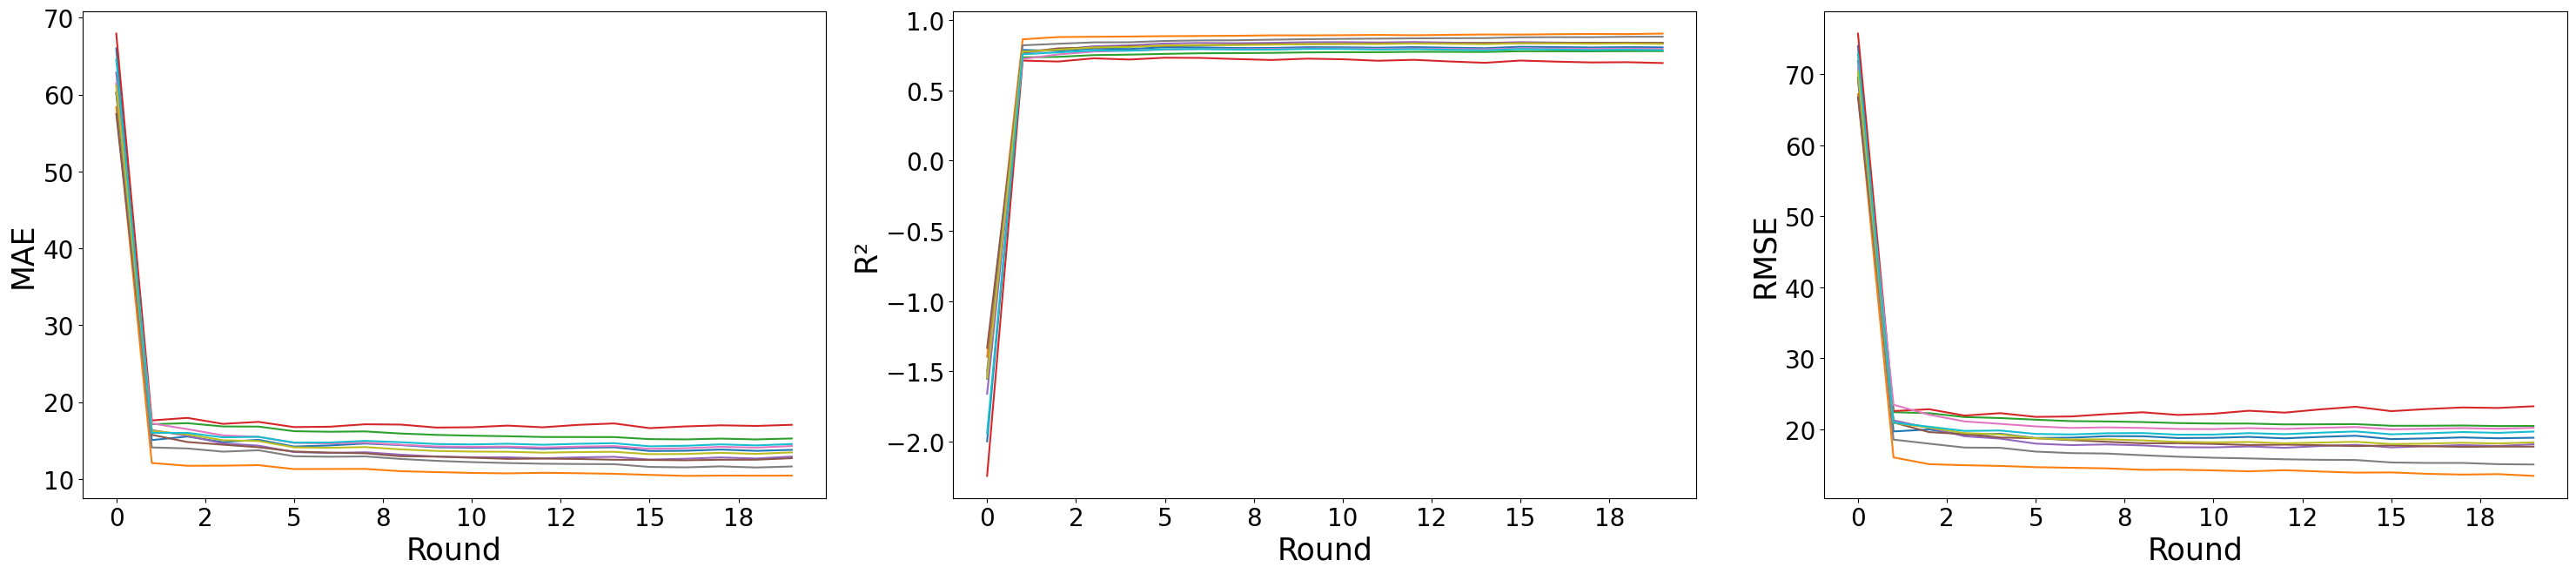

In [24]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(30, 7))
plt.rcParams.update({'font.size': 20})

# Plot MAE
ax1.plot(global_stats_mae_2[global_stats_mae_2.columns[1:11]], label='train')
ax1.set_ylabel('MAE', fontsize=25)
ax1.set_xlabel('Round', fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=20)
ax1.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

# Plot R² instead of MAP
ax2.plot(global_stats_r2_2[global_stats_r2_2.columns[1:11]], label='train')
ax2.set_ylabel('R²', fontsize=25)
ax2.set_xlabel('Round', fontsize=25)
ax2.tick_params(axis='both', which='major', labelsize=20)
ax2.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

# Plot RMSE
ax3.plot(global_stats_rmse_2[global_stats_rmse_2.columns[1:11]], label='train')
ax3.set_ylabel('RMSE', fontsize=25)
ax3.set_xlabel('Round', fontsize=25)
ax3.tick_params(axis='both', which='major', labelsize=20)
ax3.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

plt.tight_layout()
plt.show()
#pyplot.savefig(f'federated-metrics-datasets_FedProx_{EPOCHS}_{comms_round}.png', bbox_inches='tight', dpi=400)

In [25]:
global_stats_mae_2['A'] = (global_stats_mae_2['0'] + global_stats_mae_2['1'] + global_stats_mae_2['2'] + global_stats_mae_2['3'] +
                         global_stats_mae_2['4'] + global_stats_mae_2['5'] + global_stats_mae_2['6'] + global_stats_mae_2['7'] +
                         global_stats_mae_2['8'] + global_stats_mae_2['9'] + global_stats_mae_2['test']) / 11

global_stats_r2_2['A'] = (global_stats_r2_2['0'] + global_stats_r2_2['1'] + global_stats_r2_2['2'] + global_stats_r2_2['3'] +
                          global_stats_r2_2['4'] + global_stats_r2_2['5'] + global_stats_r2_2['6'] + global_stats_r2_2['7'] +
                          global_stats_r2_2['8'] + global_stats_r2_2['9'] + global_stats_r2_2['test']) / 11

global_stats_rmse_2['A'] = (global_stats_rmse_2['0'] + global_stats_rmse_2['1'] + global_stats_rmse_2['2'] + global_stats_rmse_2['3'] +
                          global_stats_rmse_2['4'] + global_stats_rmse_2['5'] + global_stats_rmse_2['6'] + global_stats_rmse_2['7'] +
                          global_stats_rmse_2['8'] + global_stats_rmse_2['9'] + global_stats_rmse_2['test']) / 11

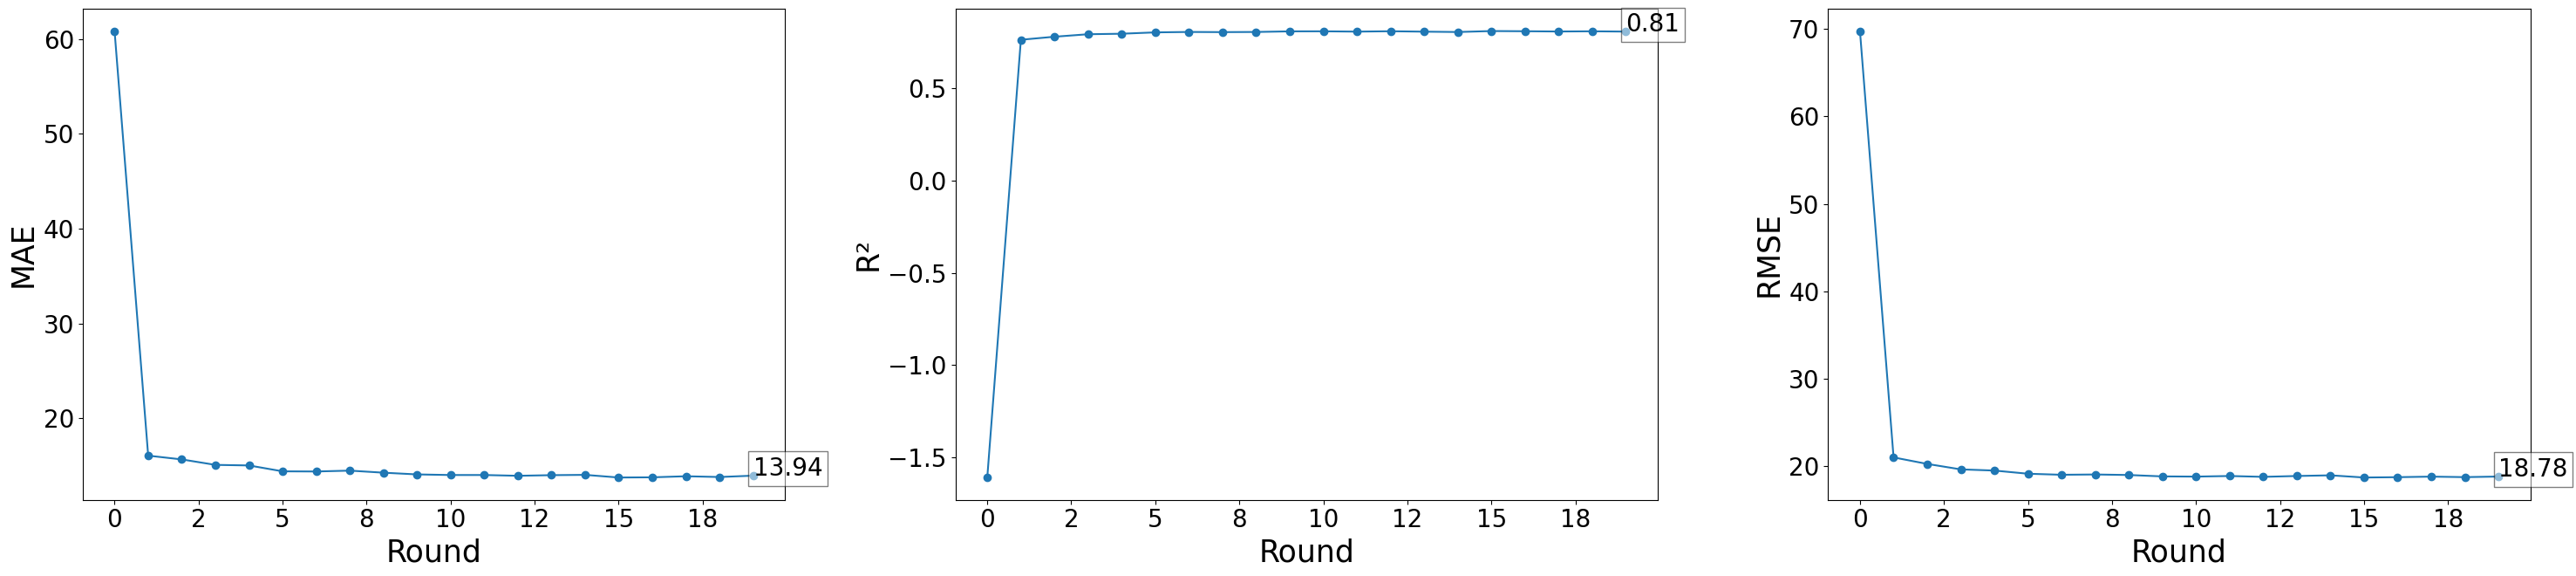

In [26]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(30, 7))
plt.rcParams.update({'font.size': 20})

# Plot MAE
ax1.plot(global_stats_mae_2['A'], label='train', marker='o')
ax1.set_ylabel('MAE', fontsize=25)
ax1.set_xlabel('Round', fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=20)
ax1.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

# Plot R² instead of MAPE
ax2.plot(global_stats_r2_2['A'], label='train', marker='o')
ax2.set_ylabel('R²', fontsize=25)
ax2.set_xlabel('Round', fontsize=25)
ax2.tick_params(axis='both', which='major', labelsize=20)
ax2.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

# Plot RMSE
ax3.plot(global_stats_rmse_2['A'], label='train', marker='o')
ax3.set_ylabel('RMSE', fontsize=25)
ax3.set_xlabel('Round', fontsize=25)
ax3.tick_params(axis='both', which='major', labelsize=20)
ax3.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

# Add text annotations for the last round values
round_idx = len(global_stats_mae_2) - 1
ax1.text(round_idx, global_stats_mae_2['A'][round_idx], f'{global_stats_mae_2["A"][round_idx]:.2f}', bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
ax2.text(round_idx, global_stats_r2_2['A'][round_idx], f'{global_stats_r2_2["A"][round_idx]:.2f}', bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
ax3.text(round_idx, global_stats_rmse_2['A'][round_idx], f'{global_stats_rmse_2["A"][round_idx]:.2f}', bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))

plt.tight_layout()
plt.show()

#pyplot.savefig(f'federated-metrics_FedProx_{EPOCHS}_{comms_round}.png', bbox_inches='tight', dpi=400)

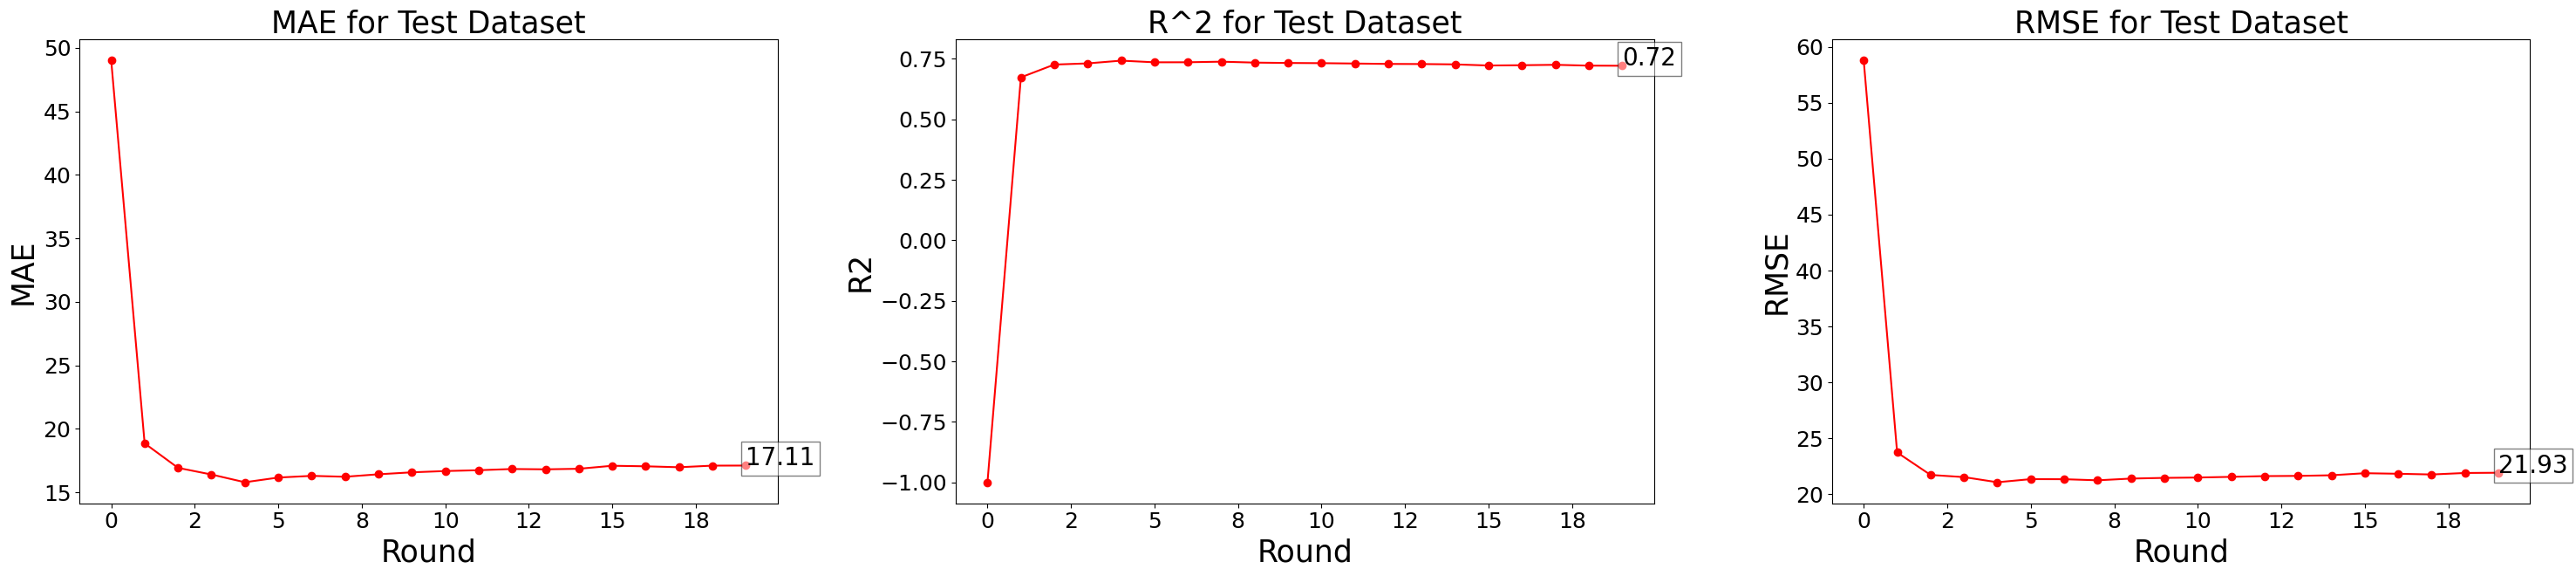

In [27]:
fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(30, 7))

ax1.plot(global_stats_mae_2['test'], label='test', marker='o', color='red')
ax1.set_ylabel('MAE', fontsize=25)
ax1.set_xlabel('Round', fontsize=25)
ax1.tick_params(axis='both', which='major', labelsize=18)
ax1.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

ax2.plot(global_stats_r2_2['test'], label='test', marker='o', color='red')
ax2.set_ylabel('R2', fontsize=25)
ax2.set_xlabel('Round', fontsize=25)
ax2.tick_params(axis='both', which='major', labelsize=18)
ax2.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

ax3.plot(global_stats_rmse_2['test'], label='test', marker='o', color='red')
ax3.set_ylabel('RMSE', fontsize=25)
ax3.set_xlabel('Round', fontsize=25)
ax3.tick_params(axis='both', which='major', labelsize=18)
ax3.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

round_idx = len(global_stats_mae_2) - 1  
ax1.text(round_idx, global_stats_mae_2['test'][round_idx], f'{global_stats_mae_2["test"][round_idx]:.2f}', bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
ax2.text(round_idx, global_stats_r2_2['test'][round_idx], f'{global_stats_r2_2["test"][round_idx]:.2f}', bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
ax3.text(round_idx, global_stats_rmse_2['test'][round_idx], f'{global_stats_rmse_2["test"][round_idx]:.2f}', bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))

ax1.set_title('MAE for Test Dataset', fontsize=25)
ax2.set_title('R^2 for Test Dataset', fontsize=25)
ax3.set_title('RMSE for Test Dataset', fontsize=25)

plt.tight_layout()

plt.show()

In [28]:
global_stats_mae_2.to_csv('global_stats_mae_FedProx.csv', index=False)
global_stats_r2_2.to_csv('global_stats_r2_FedProx.csv', index=False)
global_stats_rmse_2.to_csv('global_stats_rmse_FedProx.csv', index=False)